In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import requests
from bs4 import BeautifulSoup
import time
from statsmodels.iolib.summary2 import summary_col

In [2]:
def read_and_parse_data(url):
    data = pd.read_csv(url)
    team_map = {
    "Sociedad": "Real Sociedad",
    "Vallecano": "Rayo Vallecano",
    "Espanol": "Espanyol",
    "Huesca": "SD Huesca",
    "Ath Bilbao": "Athletic Club",
    "La Coruna": "Deportivo La Coruna",
    "Sp Gijon": "Sporting Gijon",
    "Betis": "Real Betis",
    "Celta": "Celta Vigo",
    "Valladolid": "Real Valladolid",
    "Ath Madrid": "Atletico Madrid"
}
    data["HomeTeam"] = data["HomeTeam"].replace(team_map)
    data["AwayTeam"] = data["AwayTeam"].replace(team_map)

    data.drop("Div",axis=1,inplace=True)
    data["Date"] = pd.to_datetime(
    data["Date"],
    dayfirst=True,
    errors="coerce"
)
    start_year = data["Date"].dt.year.where(
    data["Date"].dt.month >= 7,
    data["Date"].dt.year - 1
)
    data["Season"] = (
    start_year.astype(str)
    + "-"
    + (start_year + 1).astype(str)
)


    return data

In [3]:
data_2015 = read_and_parse_data("Team_Data/La Liga 2015-16.csv")
data_2016 = read_and_parse_data("Team_Data/La Liga 2016-17.csv")
data_2017 = read_and_parse_data("Team_Data/La Liga 2017-18.csv")
data_2018 = read_and_parse_data("Team_Data/La Liga 2018-19.csv")
data_2019 = read_and_parse_data("Team_Data/La Liga 2019-20.csv")
data_2020 = read_and_parse_data("Team_Data/La Liga 2020-21.csv")
data_2021 = read_and_parse_data("Team_Data/La Liga 2021-22.csv")
data_2022 = read_and_parse_data("Team_Data/La Liga 2022-23.csv")

C:\Users\aarsh\AppData\Local\Temp\ipykernel_25080\3150940853.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(
C:\Users\aarsh\AppData\Local\Temp\ipykernel_25080\3150940853.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(
C:\Users\aarsh\AppData\Local\Temp\ipykernel_25080\3150940853.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(


In [4]:
def data_truncate(data):
    return data[['Date','Season','HomeTeam','AwayTeam','FTHG','FTAG','FTR','B365H','B365D','B365A']].copy()

In [5]:
data_2015 = data_truncate(data_2015)
data_2016 = data_truncate(data_2016)
data_2017 = data_truncate(data_2017)
data_2018 = data_truncate(data_2018)
data_2019 = data_truncate(data_2019)
data_2020 = data_truncate(data_2020)
data_2021 = data_truncate(data_2021)
data_2022 = data_truncate(data_2022)


In [6]:
data_2022.head(20)

,Date,Season,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A
0,2022-08-12,2022-2023,Osasuna,Sevilla,2,1,H,3.20,3.10,2.40
1,2022-08-13,2022-2023,Celta Vigo,Espanyol,2,2,D,1.80,3.75,4.75
2,2022-08-13,2022-2023,Real Valladolid,Villarreal,0,3,A,3.90,3.60,1.90
3,2022-08-13,2022-2023,Barcelona,Rayo Vallecano,0,0,D,1.22,7.00,12.00
4,2022-08-14,2022-2023,Cadiz,Real Sociedad,0,1,A,3.60,3.20,2.20
5,2022-08-14,2022-2023,Valencia,Girona,1,0,H,1.85,3.40,4.50
6,2022-08-14,2022-2023,Almeria,Real Madrid,1,2,A,7.50,5.00,1.40
7,2022-08-15,2022-2023,Athletic Club,Mallorca,0,0,D,1.60,3.75,6.50
8,2022-08-15,2022-2023,Getafe,Atletico Madrid,0,3,A,5.00,3.10,1.90
9,2022-08-15,2022-2023,Real Betis,Elche,3,0,H,1.44,4.50,7.00


In [7]:
def odds_calculation(data_trunc):
    data_trunc['hwin_prob_B365'] = (1/data_trunc['B365H']) / ((1/data_trunc['B365H']) + (1/data_trunc['B365D'])  + (1/data_trunc['B365A']))
    data_trunc['draw_prob_B365'] = (1/data_trunc['B365D']) / ((1/data_trunc['B365H']) + (1/data_trunc['B365D'])  + (1/data_trunc['B365A']))
    data_trunc['awin_prob_B365'] = (1/data_trunc['B365A']) / ((1/data_trunc['B365H']) + (1/data_trunc['B365D'])  + (1/data_trunc['B365A']))
    data_trunc['hwin'] = np.where(data_trunc['FTR'] == 'H',1,0)
    data_trunc['draw'] = np.where(data_trunc['FTR'] == 'D',1,0)
    data_trunc['awin'] = np.where(data_trunc['FTR'] == 'A',1,0)
    data_trunc['count'] = 1
    data_trunc['result'] = np.where(data_trunc['FTR'] == 'H' , 2, np.where(data_trunc['FTR'] == 'D',1,0))
    data_trunc['max_prob_B365'] = data_trunc[['hwin_prob_B365','draw_prob_B365','awin_prob_B365']].max(axis=1)
    data_trunc['Outcome_B365'] = np.where(data_trunc['max_prob_B365'] == data_trunc['hwin_prob_B365'] , 'H',np.where(data_trunc['max_prob_B365'] == data_trunc['awin_prob_B365'],'A','D'))
    data_trunc['res_B365'] = np.where(data_trunc['Outcome_B365'] == 'H',2,np.where(data_trunc['Outcome_B365'] == 'D',1,0))
    data_trunc['hwin_odds'] = np.where(data_trunc['res_B365'] == 2,1,0)
    data_trunc['awin_odds'] = np.where(data_trunc['res_B365'] == 0,1,0)
    data_trunc['draw_odds'] = np.where(data_trunc['res_B365'] == 1,1,0)
    data_trunc['Brier_B365'] = (data_trunc['hwin'] - data_trunc['hwin_prob_B365']) ** 2 + (data_trunc['awin'] - data_trunc['awin_prob_B365']) ** 2 + (data_trunc['draw'] - data_trunc['draw_prob_B365']) ** 2
    data_trunc['B365_Correct'] = np.where(data_trunc['res_B365'] == data_trunc['result'],1,0)
    print(f'{data_trunc['Season'].unique()[0]} : {data_trunc['B365_Correct'].mean()}')
    return data_trunc

data_2015 = odds_calculation(data_2015)
data_2016 = odds_calculation(data_2016)
data_2017 = odds_calculation(data_2017)
data_2018 = odds_calculation(data_2018)
data_2019 = odds_calculation(data_2019)
data_2020 = odds_calculation(data_2020)
data_2021 = odds_calculation(data_2021)
data_2022 = odds_calculation(data_2022)

2015-2016 : 0.5473684210526316
2016-2017 : 0.5842105263157895
2017-2018 : 0.5473684210526316
2018-2019 : 0.48157894736842105
2019-2020 : 0.5184210526315789
2020-2021 : 0.5342105263157895
2021-2022 : 0.5184210526315789
2022-2023 : 0.5473684210526316


In [8]:
data_trunc = pd.concat([data_2015,data_2016,data_2017,data_2018,data_2019,data_2020,data_2021,data_2022],axis=0)
data_trunc.groupby("Season")["Brier_B365"].mean()

Season
2015-2016    0.550708
2016-2017    0.531931
2017-2018    0.570501
2018-2019    0.602516
2019-2020    0.590060
2020-2021    0.585475
2021-2022    0.588517
2022-2023    0.583097
Name: Brier_B365, dtype: float64

In [9]:
pd.crosstab(
    data_trunc["Outcome_B365"],   # predicted
    data_trunc["FTR"],
    normalize="index"# actual             # row-wise probabilities
)

FTR,A,D,H
Outcome_B365,,,
A,0.492927,0.273123,0.233950
D,0.000000,0.000000,1.000000
H,0.191600,0.254837,0.553563


In [10]:
for season, df_s in data_trunc.groupby("Season"):
    print(f"\nSeason: {season}")
    display(
        pd.crosstab(
            df_s["Outcome_B365"],
            df_s["FTR"]
        ).round(3)
    )



Season: 2015-2016


FTR,A,D,H
Outcome_B365,,,
A,48,27,23
H,57,65,160



Season: 2016-2017


FTR,A,D,H
Outcome_B365,,,
A,62,24,21
H,48,65,160



Season: 2017-2018


...

FTR,A,D,H
Outcome_B365,,,
A,82,48,30
H,53,74,150



Season: 2021-2022


FTR,A,D,H
Outcome_B365,,,
A,57,40,25
H,47,71,140



Season: 2022-2023


FTR,A,D,H
Outcome_B365,,,
A,65,26,37
D,0,0,2
H,44,63,143


In [11]:
data_home = data_trunc[['Date',"Season",'HomeTeam','FTHG','FTAG','count']]
data_home['home'] = 1
data_home.columns = ['Date',"Season",'Team','FTHG','FTAG','count','home']
data_home.head(10)

C:\Users\aarsh\AppData\Local\Temp\ipykernel_25080\4037043250.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_home['home'] = 1


,Date,Season,Team,FTHG,FTAG,count,home
0,2015-08-21,2015-2016,Malaga,0,0,1,1
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1
2,2015-08-22,2015-2016,Espanyol,1,0,1,1
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1
5,2015-08-23,2015-2016,Athletic Club,0,1,1,1
6,2015-08-23,2015-2016,Real Betis,1,1,1,1
7,2015-08-23,2015-2016,Levante,1,2,1,1
8,2015-08-23,2015-2016,Sporting Gijon,0,0,1,1
9,2015-08-24,2015-2016,Granada,1,3,1,1


In [12]:
data_away = data_trunc[['Date',"Season",'AwayTeam','FTAG','FTHG','count']]
data_away['home'] = 0
data_away.columns = ['Date',"Season",'Team','FTHG','FTAG','count','home']
data_away

C:\Users\aarsh\AppData\Local\Temp\ipykernel_25080\2616755642.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_away['home'] = 0


,Date,Season,Team,FTHG,FTAG,count,home
0,2015-08-21,2015-2016,Sevilla,0,0,1,0
1,2015-08-22,2015-2016,Las Palmas,0,1,1,0
2,2015-08-22,2015-2016,Getafe,0,1,1,0
3,2015-08-22,2015-2016,Real Sociedad,0,0,1,0
4,2015-08-22,2015-2016,Valencia,0,0,1,0
...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Valencia,1,1,1,0
376,2023-06-04,2022-2023,Barcelona,1,2,1,0
377,2023-06-04,2022-2023,Cadiz,1,1,1,0
378,2023-06-04,2022-2023,Almeria,3,3,1,0


In [13]:
data_final = pd.concat([data_home,data_away],axis=0)
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6080 entries, 0 to 379
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6080 non-null   datetime64[ns]
 1   Season  6080 non-null   object        
 2   Team    6080 non-null   object        
 3   FTHG    6080 non-null   int64         
 4   FTAG    6080 non-null   int64         
 5   count   6080 non-null   int64         
 6   home    6080 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 380.0+ KB


In [14]:
data_final.sort_values(by='Date',ascending=True)

,Date,Season,Team,FTHG,FTAG,count,home
0,2015-08-21,2015-2016,Malaga,0,0,1,1
0,2015-08-21,2015-2016,Sevilla,0,0,1,0
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1
2,2015-08-22,2015-2016,Espanyol,1,0,1,1
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1
...,...,...,...,...,...,...,...
372,2023-06-04,2022-2023,Real Madrid,1,1,1,1
371,2023-06-04,2022-2023,Osasuna,2,1,1,1
370,2023-06-04,2022-2023,Mallorca,3,0,1,1
378,2023-06-04,2022-2023,Almeria,3,3,1,0


In [15]:
data_final['Cumulative_Goals_For'] = data_final.groupby(["Team","Season"])['FTHG'].cumsum()
data_final

,Date,Season,Team,FTHG,FTAG,count,home,Cumulative_Goals_For
0,2015-08-21,2015-2016,Malaga,0,0,1,1,0
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1,1
2,2015-08-22,2015-2016,Espanyol,1,0,1,1,1
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1,0
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1,0
...,...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Valencia,1,1,1,0,42
376,2023-06-04,2022-2023,Barcelona,1,2,1,0,70
377,2023-06-04,2022-2023,Cadiz,1,1,1,0,30
378,2023-06-04,2022-2023,Almeria,3,3,1,0,49


In [16]:
data_final['Cumulative_Goals_Against'] = data_final.groupby(["Team","Season"])['FTAG'].cumsum()
data_final

,Date,Season,Team,FTHG,FTAG,count,home,Cumulative_Goals_For,Cumulative_Goals_Against
0,2015-08-21,2015-2016,Malaga,0,0,1,1,0,0
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1,1,0
2,2015-08-22,2015-2016,Espanyol,1,0,1,1,1,0
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1,0,0
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Valencia,1,1,1,0,42,45
376,2023-06-04,2022-2023,Barcelona,1,2,1,0,70,20
377,2023-06-04,2022-2023,Cadiz,1,1,1,0,30,53
378,2023-06-04,2022-2023,Almeria,3,3,1,0,49,65


In [17]:
data_final['pyth_exp'] = data_final['Cumulative_Goals_For'] ** 2 / (data_final['Cumulative_Goals_For'] ** 2  + data_final['Cumulative_Goals_Against'] ** 2 )
data_final

,Date,Season,Team,FTHG,FTAG,count,home,Cumulative_Goals_For,Cumulative_Goals_Against,pyth_exp
0,2015-08-21,2015-2016,Malaga,0,0,1,1,0,0,NaN
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1,1,0,1.000000
2,2015-08-22,2015-2016,Espanyol,1,0,1,1,1,0,1.000000
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1,0,0,NaN
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Valencia,1,1,1,0,42,45,0.465558
376,2023-06-04,2022-2023,Barcelona,1,2,1,0,70,20,0.924528
377,2023-06-04,2022-2023,Cadiz,1,1,1,0,30,53,0.242653
378,2023-06-04,2022-2023,Almeria,3,3,1,0,49,65,0.362360


In [18]:
data_final['Games_Till_Date'] = data_final.groupby(["Team","Season"])['count'].cumsum()
data_final

,Date,Season,Team,FTHG,FTAG,count,home,Cumulative_Goals_For,Cumulative_Goals_Against,pyth_exp,Games_Till_Date
0,2015-08-21,2015-2016,Malaga,0,0,1,1,0,0,NaN,1
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1,1,0,1.000000,1
2,2015-08-22,2015-2016,Espanyol,1,0,1,1,1,0,1.000000,1
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1,0,0,NaN,1
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1,0,0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Valencia,1,1,1,0,42,45,0.465558,38
376,2023-06-04,2022-2023,Barcelona,1,2,1,0,70,20,0.924528,38
377,2023-06-04,2022-2023,Cadiz,1,1,1,0,30,53,0.242653,38
378,2023-06-04,2022-2023,Almeria,3,3,1,0,49,65,0.362360,38


In [19]:
data_final['win'] = np.where(data_final['FTHG'] > data_final['FTAG'] , 1,0)
data_final.head(20)

,Date,Season,Team,FTHG,FTAG,count,home,Cumulative_Goals_For,Cumulative_Goals_Against,pyth_exp,Games_Till_Date,win
0,2015-08-21,2015-2016,Malaga,0,0,1,1,0,0,NaN,1,0
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1,1,0,1.0,1,1
2,2015-08-22,2015-2016,Espanyol,1,0,1,1,1,0,1.0,1,1
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1,0,0,NaN,1,0
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1,0,0,NaN,1,0
5,2015-08-23,2015-2016,Athletic Club,0,1,1,1,0,1,0.0,1,0
6,2015-08-23,2015-2016,Real Betis,1,1,1,1,1,1,0.5,1,0
7,2015-08-23,2015-2016,Levante,1,2,1,1,1,2,0.2,1,0
8,2015-08-23,2015-2016,Sporting Gijon,0,0,1,1,0,0,NaN,1,0
9,2015-08-24,2015-2016,Granada,1,3,1,1,1,3,0.1,1,0


In [20]:
data_final['pyth_exp_lag'] = data_final.groupby(["Team","Season"])['pyth_exp'].shift(1)
data_final

,Date,Season,Team,FTHG,FTAG,count,home,Cumulative_Goals_For,Cumulative_Goals_Against,pyth_exp,Games_Till_Date,win,pyth_exp_lag
0,2015-08-21,2015-2016,Malaga,0,0,1,1,0,0,NaN,1,0,NaN
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1,1,0,1.000000,1,1,NaN
2,2015-08-22,2015-2016,Espanyol,1,0,1,1,1,0,1.000000,1,1,NaN
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1,0,0,NaN,1,0,NaN
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1,0,0,NaN,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Valencia,1,1,1,0,42,45,0.465558,38,0,0.464750
376,2023-06-04,2022-2023,Barcelona,1,2,1,0,70,20,0.924528,38,0,0.936283
377,2023-06-04,2022-2023,Cadiz,1,1,1,0,30,53,0.242653,38,0,0.237236
378,2023-06-04,2022-2023,Almeria,3,3,1,0,49,65,0.362360,38,0,0.355034


In [21]:
data_final['Wins_Till_Date'] = data_final.groupby(["Team","Season"])['win'].cumsum()
data_final

,Date,Season,Team,FTHG,FTAG,count,home,Cumulative_Goals_For,Cumulative_Goals_Against,pyth_exp,Games_Till_Date,win,pyth_exp_lag,Wins_Till_Date
0,2015-08-21,2015-2016,Malaga,0,0,1,1,0,0,NaN,1,0,NaN,0
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1,1,0,1.000000,1,1,NaN,1
2,2015-08-22,2015-2016,Espanyol,1,0,1,1,1,0,1.000000,1,1,NaN,1
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1,0,0,NaN,1,0,NaN,0
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1,0,0,NaN,1,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Valencia,1,1,1,0,42,45,0.465558,38,0,0.464750,11
376,2023-06-04,2022-2023,Barcelona,1,2,1,0,70,20,0.924528,38,0,0.936283,28
377,2023-06-04,2022-2023,Cadiz,1,1,1,0,30,53,0.242653,38,0,0.237236,10
378,2023-06-04,2022-2023,Almeria,3,3,1,0,49,65,0.362360,38,0,0.355034,11


In [22]:
data_final['Win_Percentage_Till_Date'] = data_final['Wins_Till_Date'] / data_final['Games_Till_Date']
data_final

,Date,Season,Team,FTHG,FTAG,count,home,Cumulative_Goals_For,Cumulative_Goals_Against,pyth_exp,Games_Till_Date,win,pyth_exp_lag,Wins_Till_Date,Win_Percentage_Till_Date
0,2015-08-21,2015-2016,Malaga,0,0,1,1,0,0,NaN,1,0,NaN,0,0.000000
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1,1,0,1.000000,1,1,NaN,1,1.000000
2,2015-08-22,2015-2016,Espanyol,1,0,1,1,1,0,1.000000,1,1,NaN,1,1.000000
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1,0,0,NaN,1,0,NaN,0,0.000000
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1,0,0,NaN,1,0,NaN,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Valencia,1,1,1,0,42,45,0.465558,38,0,0.464750,11,0.289474
376,2023-06-04,2022-2023,Barcelona,1,2,1,0,70,20,0.924528,38,0,0.936283,28,0.736842
377,2023-06-04,2022-2023,Cadiz,1,1,1,0,30,53,0.242653,38,0,0.237236,10,0.263158
378,2023-06-04,2022-2023,Almeria,3,3,1,0,49,65,0.362360,38,0,0.355034,11,0.289474


In [23]:
data_final

,Date,Season,Team,FTHG,FTAG,count,home,Cumulative_Goals_For,Cumulative_Goals_Against,pyth_exp,Games_Till_Date,win,pyth_exp_lag,Wins_Till_Date,Win_Percentage_Till_Date
0,2015-08-21,2015-2016,Malaga,0,0,1,1,0,0,NaN,1,0,NaN,0,0.000000
1,2015-08-22,2015-2016,Atletico Madrid,1,0,1,1,1,0,1.000000,1,1,NaN,1,1.000000
2,2015-08-22,2015-2016,Espanyol,1,0,1,1,1,0,1.000000,1,1,NaN,1,1.000000
3,2015-08-22,2015-2016,Deportivo La Coruna,0,0,1,1,0,0,NaN,1,0,NaN,0,0.000000
4,2015-08-22,2015-2016,Rayo Vallecano,0,0,1,1,0,0,NaN,1,0,NaN,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Valencia,1,1,1,0,42,45,0.465558,38,0,0.464750,11,0.289474
376,2023-06-04,2022-2023,Barcelona,1,2,1,0,70,20,0.924528,38,0,0.936283,28,0.736842
377,2023-06-04,2022-2023,Cadiz,1,1,1,0,30,53,0.242653,38,0,0.237236,10,0.263158
378,2023-06-04,2022-2023,Almeria,3,3,1,0,49,65,0.362360,38,0,0.355034,11,0.289474


In [24]:
data_final = data_final.dropna()

In [25]:
game_wise_lm = smf.ols(formula = "Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_final).fit()
game_wise_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     Win_Percentage_Till_Date   R-squared:                       0.719
Model:                                  OLS   Adj. R-squared:                  0.719
Method:                       Least Squares   F-statistic:                 1.508e+04
Date:                      Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                              17:13:57   Log-Likelihood:                 4870.5
No. Observations:                      5891   AIC:                            -9737.
Df Residuals:                          5889   BIC:                            -9724.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0231      0.004      6.586      0.000       0.016       0.030
pyth_exp_lag     0.7083      0.006    122.791      0.000       0.697       0.720
==============================================================================
Omnibus:                      497.083   Durbin-Watson:                   2.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2157.256
Skew:                           0.311   Prob(JB):                         0.00
Kurtosis:                       5.899   Cond. No.                         5.55
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
game_wise_lm_2 = smf.ols(formula = "win ~ pyth_exp_lag",data=data_final).fit()
game_wise_lm_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    win   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     299.3
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.94e-65
Time:                        17:13:57   Log-Likelihood:                -3926.4
No. Observations:                5891   AIC:                             7857.
Df Residuals:                    5889   BIC:                             7870.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1221      0.016      7.807      0.000       0.091       0.153
pyth_exp_lag     0.4442      0.026     17.299      0.000       0.394       0.495
==============================================================================
Omnibus:                    33616.071   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              830.086
Skew:                           0.506   Prob(JB):                    5.61e-181
Kurtosis:                       1.465   Cond. No.                         5.55
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
team_wise_data = {}
for i in data_final['Team'].unique():
    data_temp = data_final[data_final['Team'] == i]
    team_wise_lm = smf.ols(formula="Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_temp).fit()
    team_wise_data[i] = team_wise_lm.rsquared
    

In [28]:
team_wise_data = pd.DataFrame(team_wise_data,index=[0]).T.reset_index()
team_wise_data.columns = ["Team","R-Squared"]
team_wise_data

,Team,R-Squared
0,Levante,0.506557
1,Atletico Madrid,0.431583
2,Real Betis,0.568494
3,Espanyol,0.602078
4,Athletic Club,0.476131
5,Celta Vigo,0.196378
6,Granada,0.751132
7,Getafe,0.665643
8,Eibar,0.533775
9,Real Madrid,0.413406


In [29]:
team_wise_data.sort_values(by="R-Squared",ascending=False)

,Team,R-Squared
15,Rayo Vallecano,0.762435
6,Granada,0.751132
20,Osasuna,0.744148
23,Girona,0.732226
13,Villarreal,0.707632
25,SD Huesca,0.701544
21,Leganes,0.697943
12,Sevilla,0.683916
7,Getafe,0.665643
14,Las Palmas,0.663863


In [30]:
data_2015 = data_final.loc[data_final['Season'] == "2015-2016",:]
data_2016 = data_final.loc[data_final['Season'] == "2016-2017",:]
data_2017 = data_final.loc[data_final['Season'] == "2017-2018",:]
data_2018 = data_final.loc[data_final['Season'] == "2018-2019",:]
data_2019 = data_final.loc[data_final['Season'] == "2019-2020",:]
data_2020 = data_final.loc[data_final['Season'] == "2020-2021",:]
data_2021 = data_final.loc[data_final['Season'] == "2021-2022",:]
data_2022 = data_final.loc[data_final['Season'] == "2022-2023",:]


In [31]:
game_wise_lm_2015 = smf.ols(formula = "Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_2015).fit()
game_wise_lm_2016 = smf.ols(formula = "Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_2016).fit()
game_wise_lm_2017 = smf.ols(formula = "Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_2017).fit()
game_wise_lm_2018 = smf.ols(formula = "Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_2018).fit()
game_wise_lm_2019 = smf.ols(formula = "Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_2019).fit()
game_wise_lm_2020 = smf.ols(formula = "Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_2020).fit()
game_wise_lm_2021 = smf.ols(formula = "Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_2021).fit()
game_wise_lm_2022 = smf.ols(formula = "Win_Percentage_Till_Date ~ pyth_exp_lag",data=data_2022).fit()


In [32]:
info_dict={'R-squared' : lambda x: f"{x.rsquared:.2f}",
           'No. observations' : lambda x: f"{int(x.nobs):d}"}
AllYears = ["All",'2015','2016','2017','2018','2019','2020','2021','2022']
gamewise_All = summary_col([game_wise_lm,game_wise_lm_2015,game_wise_lm_2016,game_wise_lm_2017,game_wise_lm_2018,game_wise_lm_2019,game_wise_lm_2020,game_wise_lm_2021,game_wise_lm_2022],model_names = AllYears, stars=True, info_dict = info_dict)
gamewise_All

,All,2015,2016,2017,2018,2019,2020,2021,2022
Intercept,0.0231***,0.0454***,-0.0008,0.0926***,-0.0106,0.0321**,0.0094,-0.0258***,0.0349***
,(0.0035),(0.0113),(0.0096),(0.0089),(0.0109),(0.0125),(0.0074),(0.0097),(0.0091)
pyth_exp_lag,0.7083***,0.6892***,0.7868***,0.6136***,0.7334***,0.6675***,0.7294***,0.7517***,0.7113***
,(0.0058),(0.0184),(0.0159),(0.0144),(0.0183),(0.0194),(0.0130),(0.0159),(0.0149)
R-squared,0.7191,0.6586,0.7697,0.7111,0.6870,0.6552,0.7890,0.7538,0.7567
R-squared Adj.,0.7191,0.6581,0.7694,0.7108,0.6866,0.6546,0.7887,0.7534,0.7563
No. observations,5891,733,735,739,737,625,849,735,738
R-squared,0.72,0.66,0.77,0.71,0.69,0.66,0.79,0.75,0.76


In [33]:
team_data = data_trunc.copy()
team_data

,Date,Season,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,...,count,result,max_prob_B365,Outcome_B365,res_B365,hwin_odds,awin_odds,draw_odds,Brier_B365,B365_Correct
0,2015-08-21,2015-2016,Malaga,Sevilla,0,0,D,3.40,3.4,2.15,...,1,1,0.441558,A,0,0,1,0,0.792461,0
1,2015-08-22,2015-2016,Atletico Madrid,Las Palmas,1,0,H,1.20,6.5,15.00,...,1,2,0.790754,H,2,1,0,0,0.069097,1
2,2015-08-22,2015-2016,Espanyol,Getafe,1,0,H,1.91,3.4,4.33,...,1,2,0.499283,H,2,1,0,0,0.377891,1
3,2015-08-22,2015-2016,Deportivo La Coruna,Real Sociedad,0,0,D,2.50,3.2,3.00,...,1,1,0.382470,H,2,1,0,0,0.739544,0
4,2015-08-22,2015-2016,Rayo Vallecano,Valencia,0,0,D,3.60,3.5,2.05,...,1,1,0.464003,A,0,0,1,0,0.815427,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,2023-06-04,2022-2023,Real Betis,Valencia,1,1,D,2.63,3.6,2.50,...,1,1,0.378070,A,0,0,1,0,0.815927,0
376,2023-06-04,2022-2023,Celta Vigo,Barcelona,2,1,H,2.60,3.8,2.50,...,1,2,0.381762,A,0,0,1,0,0.609412,0
377,2023-06-04,2022-2023,Elche,Cadiz,1,1,D,2.63,3.4,2.63,...,1,1,0.360551,H,2,1,0,0,0.779984,0
378,2023-06-04,2022-2023,Espanyol,Almeria,3,3,D,2.75,3.8,2.38,...,1,1,0.401321,A,0,0,1,0,0.842165,0


In [34]:
data_home = team_data.groupby(["HomeTeam","Season"])[['FTHG','FTAG','hwin','count','hwin_odds']].sum().reset_index()
data_home.columns = ["Team","Season","FTHGh","FTAGh","Home Wins","Home Games",'Home_Wins_Odds']
data_home

,Team,Season,FTHGh,FTAGh,Home Wins,Home Games,Home_Wins_Odds
0,Alaves,2016-2017,19,21,7,19,12
1,Alaves,2017-2018,21,23,9,19,11
2,Alaves,2018-2019,19,19,7,19,8
3,Alaves,2019-2020,20,12,7,16,9
4,Alaves,2020-2021,21,32,6,22,10
...,...,...,...,...,...,...,...
158,Villarreal,2018-2019,28,26,5,19,16
159,Villarreal,2019-2020,31,19,8,16,14
160,Villarreal,2020-2021,35,29,9,22,18
161,Villarreal,2021-2022,40,18,10,19,17


In [35]:
data_away = team_data.groupby(["AwayTeam","Season"])[['FTHG','FTAG','awin','count','awin_odds']].sum().reset_index()
data_away.columns = ["Team","Season","FTHGa","FTAGa","Away Wins","Away Games","Away_Wins_Odds"]
data_away

,Team,Season,FTHGa,FTAGa,Away Wins,Away Games,Away_Wins_Odds
0,Alaves,2016-2017,22,22,7,19,0
1,Alaves,2017-2018,27,19,6,19,1
2,Alaves,2018-2019,31,20,6,19,0
3,Alaves,2019-2020,36,12,2,16,0
4,Alaves,2020-2021,36,17,4,22,1
...,...,...,...,...,...,...,...
158,Villarreal,2018-2019,26,21,5,19,6
159,Villarreal,2019-2020,21,20,7,16,7
160,Villarreal,2020-2021,24,37,9,22,13
161,Villarreal,2021-2022,19,23,6,19,12


In [36]:
data_team_wise_final = pd.merge(data_home,data_away,on=["Team","Season"])
data_team_wise_final

,Team,Season,FTHGh,FTAGh,Home Wins,Home Games,Home_Wins_Odds,FTHGa,FTAGa,Away Wins,Away Games,Away_Wins_Odds
0,Alaves,2016-2017,19,21,7,19,12,22,22,7,19,0
1,Alaves,2017-2018,21,23,9,19,11,27,19,6,19,1
2,Alaves,2018-2019,19,19,7,19,8,31,20,6,19,0
3,Alaves,2019-2020,20,12,7,16,9,36,12,2,16,0
4,Alaves,2020-2021,21,32,6,22,10,36,17,4,22,1
...,...,...,...,...,...,...,...,...,...,...,...,...
158,Villarreal,2018-2019,28,26,5,19,16,26,21,5,19,6
159,Villarreal,2019-2020,31,19,8,16,14,21,20,7,16,7
160,Villarreal,2020-2021,35,29,9,22,18,24,37,9,22,13
161,Villarreal,2021-2022,40,18,10,19,17,19,23,6,19,12


In [37]:
data_team_wise_final['Goals For'] = data_team_wise_final['FTHGh'] + data_team_wise_final['FTAGa']
data_team_wise_final['Goals Against'] = data_team_wise_final['FTHGa'] + data_team_wise_final['FTAGh']
data_team_wise_final['Games'] = data_team_wise_final['Home Games'] + data_team_wise_final['Away Games']
data_team_wise_final['Wins'] = data_team_wise_final['Home Wins'] + data_team_wise_final['Away Wins']
data_team_wise_final['Wins_Odds'] = data_team_wise_final['Home_Wins_Odds'] + data_team_wise_final['Away_Wins_Odds']


In [38]:
data_team_wise_final['win_pct'] = data_team_wise_final['Wins'] / data_team_wise_final['Games']
data_team_wise_final['win_pct_odds'] = data_team_wise_final['Wins_Odds'] / data_team_wise_final['Games']

data_team_wise_final['pyth_expc'] = data_team_wise_final['Goals For']**2 / (data_team_wise_final['Goals For']**2 + data_team_wise_final['Goals Against']**2)

In [39]:
data_team_wise_final

,Team,Season,FTHGh,FTAGh,Home Wins,Home Games,Home_Wins_Odds,FTHGa,FTAGa,Away Wins,Away Games,Away_Wins_Odds,Goals For,Goals Against,Games,Wins,Wins_Odds,win_pct,win_pct_odds,pyth_expc
0,Alaves,2016-2017,19,21,7,19,12,22,22,7,19,0,41,43,38,14,12,0.368421,0.315789,0.476204
1,Alaves,2017-2018,21,23,9,19,11,27,19,6,19,1,40,50,38,15,12,0.394737,0.315789,0.390244
2,Alaves,2018-2019,19,19,7,19,8,31,20,6,19,0,39,50,38,13,8,0.342105,0.210526,0.378264
3,Alaves,2019-2020,20,12,7,16,9,36,12,2,16,0,32,48,32,9,9,0.281250,0.281250,0.307692
4,Alaves,2020-2021,21,32,6,22,10,36,17,4,22,1,38,68,44,10,11,0.227273,0.250000,0.237970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,Villarreal,2018-2019,28,26,5,19,16,26,21,5,19,6,49,52,38,10,22,0.263158,0.578947,0.470323
159,Villarreal,2019-2020,31,19,8,16,14,21,20,7,16,7,51,40,32,15,21,0.468750,0.656250,0.619138
160,Villarreal,2020-2021,35,29,9,22,18,24,37,9,22,13,72,53,44,18,31,0.409091,0.704545,0.648567
161,Villarreal,2021-2022,40,18,10,19,17,19,23,6,19,12,63,37,38,16,29,0.421053,0.763158,0.743537


In [40]:
print("Correlation between Win Percentage and Pythagorean Expectation \n")
print("Overall Correlation:",data_team_wise_final['win_pct'].corr(data_team_wise_final['pyth_expc']))
for season in data_team_wise_final['Season'].unique():
    data_temp = data_team_wise_final.loc[data_team_wise_final['Season'] == season,:]
    print(f'Season {season} : {data_temp['win_pct'].corr(data_temp['pyth_expc'])}')

Correlation between Win Percentage and Pythagorean Expectation 

Overall Correlation: 0.9411519548713065
Season 2016-2017 : 0.9732933773769853
Season 2017-2018 : 0.9404067102394863
Season 2018-2019 : 0.9131763470484175
Season 2019-2020 : 0.94558517325265
Season 2020-2021 : 0.9594325901683065
Season 2021-2022 : 0.9226024968273031
Season 2022-2023 : 0.9501146554125763
Season 2015-2016 : 0.9429164011230056


In [41]:
pyth_exp_lm = smf.ols(formula='win_pct~pyth_expc',data=data_team_wise_final).fit()
pyth_exp_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                win_pct   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     1248.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           9.46e-78
Time:                        17:13:59   Log-Likelihood:                 246.15
No. Observations:                 163   AIC:                            -488.3
Df Residuals:                     161   BIC:                            -482.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0248      0.011      2.340      0.021       0.004       0.046
pyth_expc      0.7067      0.020     35.333      0.000       0.667       0.746
==============================================================================
Omnibus:                        1.294   Durbin-Watson:                   1.756
Prob(Omnibus):                  0.524   Jarque-Bera (JB):                1.206
Skew:                           0.067   Prob(JB):                        0.547
Kurtosis:                       2.601   Cond. No.                         5.91
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [42]:
data_team_wise_2015 = data_team_wise_final.loc[data_team_wise_final['Season'] == "2015-2016",:]
data_team_wise_2016 = data_team_wise_final.loc[data_team_wise_final['Season'] == "2016-2017",:]
data_team_wise_2017 = data_team_wise_final.loc[data_team_wise_final['Season'] == "2017-2018",:]
data_team_wise_2018 = data_team_wise_final.loc[data_team_wise_final['Season'] == "2018-2019",:]
data_team_wise_2019 = data_team_wise_final.loc[data_team_wise_final['Season'] == "2019-2020",:]
data_team_wise_2020 = data_team_wise_final.loc[data_team_wise_final['Season'] == "2020-2021",:]
data_team_wise_2021 = data_team_wise_final.loc[data_team_wise_final['Season'] == "2021-2022",:]
data_team_wise_2022 = data_team_wise_final.loc[data_team_wise_final['Season'] == "2022-2023",:]

pyth_exp_lm_2015 = smf.ols(formula='win_pct~pyth_expc',data=data_team_wise_2015).fit()
pyth_exp_lm_2016 = smf.ols(formula='win_pct~pyth_expc',data=data_team_wise_2016).fit()
pyth_exp_lm_2017 = smf.ols(formula='win_pct~pyth_expc',data=data_team_wise_2017).fit()
pyth_exp_lm_2018 = smf.ols(formula='win_pct~pyth_expc',data=data_team_wise_2018).fit()
pyth_exp_lm_2019 = smf.ols(formula='win_pct~pyth_expc',data=data_team_wise_2019).fit()
pyth_exp_lm_2020 = smf.ols(formula='win_pct~pyth_expc',data=data_team_wise_2020).fit()
pyth_exp_lm_2021 = smf.ols(formula='win_pct~pyth_expc',data=data_team_wise_2021).fit()
pyth_exp_lm_2022 = smf.ols(formula='win_pct~pyth_expc',data=data_team_wise_2022).fit()


In [43]:

teamwise_All = summary_col([pyth_exp_lm,pyth_exp_lm_2015,pyth_exp_lm_2016,pyth_exp_lm_2017,pyth_exp_lm_2018,pyth_exp_lm_2019,pyth_exp_lm_2020,pyth_exp_lm_2021,pyth_exp_lm_2022],model_names = AllYears, stars=True, info_dict = info_dict)
teamwise_All

,All,2015,2016,2017,2018,2019,2020,2021,2022
Intercept,0.0248**,0.0312,-0.0026,0.0675**,0.0072,0.0352,0.0066,0.0365,0.0338
,(0.0106),(0.0319),(0.0236),(0.0299),(0.0385),(0.0281),(0.0247),(0.0337),(0.0292)
pyth_expc,0.7067***,0.7309***,0.7907***,0.6596***,0.7050***,0.6551***,0.7284***,0.6435***,0.7098***
,(0.0200),(0.0608),(0.0440),(0.0562),(0.0742),(0.0531),(0.0467),(0.0634),(0.0549)
R-squared,0.8858,0.8891,0.9473,0.8844,0.8339,0.8941,0.9205,0.8512,0.9027
R-squared Adj.,0.8851,0.8829,0.9444,0.8779,0.8247,0.8882,0.9167,0.8429,0.8973
No. observations,163,20,20,20,20,20,23,20,20
R-squared,0.89,0.89,0.95,0.88,0.83,0.89,0.92,0.85,0.90


In [44]:
data_team_wise_final['win_pct_exp'] = pyth_exp_lm.predict(data_team_wise_final['pyth_expc'])
data_team_wise_final

,Team,Season,FTHGh,FTAGh,Home Wins,Home Games,Home_Wins_Odds,FTHGa,FTAGa,Away Wins,...,Away_Wins_Odds,Goals For,Goals Against,Games,Wins,Wins_Odds,win_pct,win_pct_odds,pyth_expc,win_pct_exp
0,Alaves,2016-2017,19,21,7,19,12,22,22,7,...,0,41,43,38,14,12,0.368421,0.315789,0.476204,0.361324
1,Alaves,2017-2018,21,23,9,19,11,27,19,6,...,1,40,50,38,15,12,0.394737,0.315789,0.390244,0.300573
2,Alaves,2018-2019,19,19,7,19,8,31,20,6,...,0,39,50,38,13,8,0.342105,0.210526,0.378264,0.292107
3,Alaves,2019-2020,20,12,7,16,9,36,12,2,...,0,32,48,32,9,9,0.281250,0.281250,0.307692,0.242231
4,Alaves,2020-2021,21,32,6,22,10,36,17,4,...,1,38,68,44,10,11,0.227273,0.250000,0.237970,0.192956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,Villarreal,2018-2019,28,26,5,19,16,26,21,5,...,6,49,52,38,10,22,0.263158,0.578947,0.470323,0.357168
159,Villarreal,2019-2020,31,19,8,16,14,21,20,7,...,7,51,40,32,15,21,0.468750,0.656250,0.619138,0.462341
160,Villarreal,2020-2021,35,29,9,22,18,24,37,9,...,13,72,53,44,18,31,0.409091,0.704545,0.648567,0.483140
161,Villarreal,2021-2022,40,18,10,19,17,19,23,6,...,12,63,37,38,16,29,0.421053,0.763158,0.743537,0.550258


In [45]:
data_team_wise_final['Underperformed_Expectation'] = np.where(data_team_wise_final['win_pct_exp'] > data_team_wise_final['win_pct'],1,0)
data_team_wise_final['Overperformed_Expectation'] = np.where(data_team_wise_final['win_pct_exp'] <= data_team_wise_final['win_pct'],1,0)


In [46]:
data_team_wise_final['Underperformed_Odds'] = np.where(data_team_wise_final['win_pct_odds'] > data_team_wise_final['win_pct'],1,0)
data_team_wise_final['Overperformed_Odds'] = np.where(data_team_wise_final['win_pct_odds'] <= data_team_wise_final['win_pct'],1,0)


In [47]:
data_team_wise_final

,Team,Season,FTHGh,FTAGh,Home Wins,Home Games,Home_Wins_Odds,FTHGa,FTAGa,Away Wins,...,Wins,Wins_Odds,win_pct,win_pct_odds,pyth_expc,win_pct_exp,Underperformed_Expectation,Overperformed_Expectation,Underperformed_Odds,Overperformed_Odds
0,Alaves,2016-2017,19,21,7,19,12,22,22,7,...,14,12,0.368421,0.315789,0.476204,0.361324,0,1,0,1
1,Alaves,2017-2018,21,23,9,19,11,27,19,6,...,15,12,0.394737,0.315789,0.390244,0.300573,0,1,0,1
2,Alaves,2018-2019,19,19,7,19,8,31,20,6,...,13,8,0.342105,0.210526,0.378264,0.292107,0,1,0,1
3,Alaves,2019-2020,20,12,7,16,9,36,12,2,...,9,9,0.281250,0.281250,0.307692,0.242231,0,1,0,1
4,Alaves,2020-2021,21,32,6,22,10,36,17,4,...,10,11,0.227273,0.250000,0.237970,0.192956,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,Villarreal,2018-2019,28,26,5,19,16,26,21,5,...,10,22,0.263158,0.578947,0.470323,0.357168,1,0,1,0
159,Villarreal,2019-2020,31,19,8,16,14,21,20,7,...,15,21,0.468750,0.656250,0.619138,0.462341,0,1,1,0
160,Villarreal,2020-2021,35,29,9,22,18,24,37,9,...,18,31,0.409091,0.704545,0.648567,0.483140,1,0,1,0
161,Villarreal,2021-2022,40,18,10,19,17,19,23,6,...,16,29,0.421053,0.763158,0.743537,0.550258,1,0,1,0


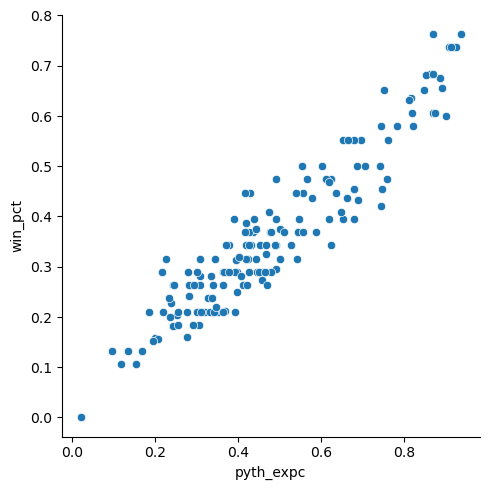

In [48]:
sns.relplot(x='pyth_expc',y='win_pct',data=data_team_wise_final)

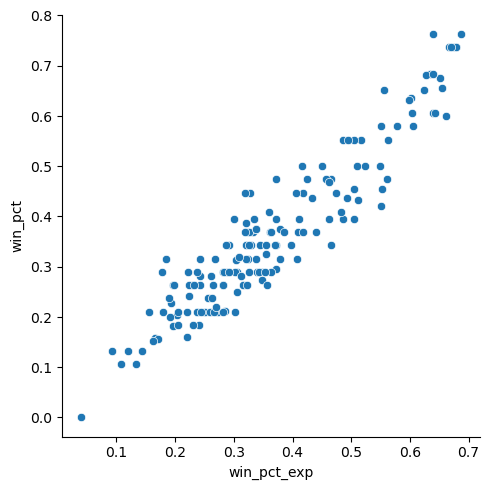

In [49]:
sns.relplot(x='win_pct_exp',y='win_pct',data=data_team_wise_final)

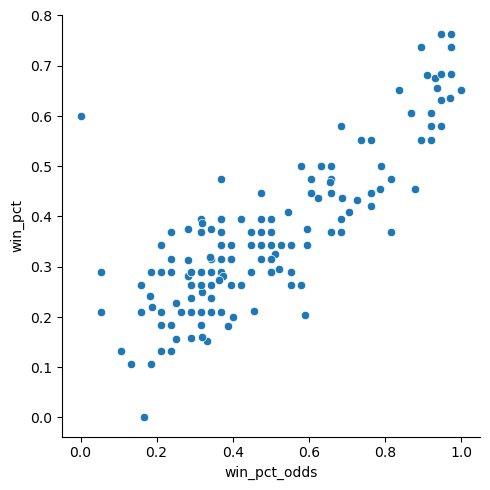

In [50]:
sns.relplot(x='win_pct_odds',y='win_pct',data=data_team_wise_final)

<Axes: xlabel='pyth_expc', ylabel='win_pct'>

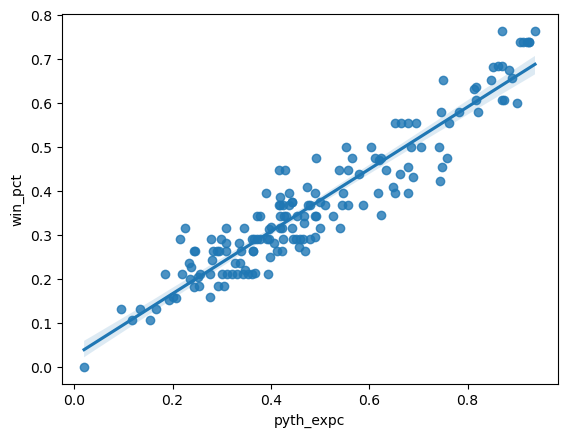

In [51]:
sns.regplot(x='pyth_expc',y='win_pct',data=data_team_wise_final)

In [52]:
win_order = data_team_wise_final.sort_values(by=["Season","win_pct",'pyth_expc'],ascending=[True,False,False])

In [53]:
win_order

,Team,Season,FTHGh,FTAGh,Home Wins,Home Games,Home_Wins_Odds,FTHGa,FTAGa,Away Wins,...,Wins,Wins_Odds,win_pct,win_pct_odds,pyth_expc,win_pct_exp,Underperformed_Expectation,Overperformed_Expectation,Underperformed_Odds,Overperformed_Odds
23,Barcelona,2015-2016,67,14,16,19,19,15,45,13,...,29,37,0.763158,0.973684,0.937168,0.687104,0,1,1,0
15,Atletico Madrid,2015-2016,33,7,15,19,17,11,30,13,...,28,34,0.736842,0.894737,0.924528,0.678171,0,1,1,0
115,Real Madrid,2015-2016,70,16,16,19,19,18,40,12,...,28,37,0.736842,0.973684,0.912794,0.669878,0,1,1,0
7,Athletic Club,2015-2016,35,17,11,19,16,28,23,7,...,18,25,0.473684,0.657895,0.624235,0.465943,0,1,1,0
155,Villarreal,2015-2016,26,12,12,19,16,23,18,6,...,18,23,0.473684,0.605263,0.612464,0.457624,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Real Valladolid,2022-2023,21,25,8,19,8,38,12,3,...,11,8,0.289474,0.210526,0.215302,0.176936,0,1,0,1
68,Getafe,2022-2023,21,20,7,19,11,25,13,3,...,10,11,0.263158,0.289474,0.363408,0.281607,1,0,1,0
33,Cadiz,2022-2023,19,23,7,19,6,30,11,3,...,10,6,0.263158,0.157895,0.242653,0.196265,0,1,0,1
61,Espanyol,2022-2023,27,35,4,19,10,34,25,4,...,8,12,0.210526,0.315789,0.362224,0.280770,1,0,1,0


In [54]:
xg_data_2015 = pd.read_csv("XG_Data/XG 2015-16.csv",sep=';')
xg_data_2015.head()

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Barcelona,38,29,4,5,112,29,91,113.60,34.03,94.38
1,2,Real Madrid,38,28,6,4,110,34,90,90.45,45.23,79.09
2,3,Atletico Madrid,38,28,4,6,63,18,88,54.93,27.80,72.28
3,4,Villarreal,38,18,10,10,44,35,64,40.49,41.63,52.11
4,5,Athletic Club,38,18,8,12,58,45,62,53.90,45.33,58.24


In [55]:
xg_data_2016 = pd.read_csv("XG_Data/XG 2016-17.csv",sep=';')
xg_data_2016.head()

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Real Madrid,38,29,6,3,106,41,93,90.87,36.86,86.17
1,2,Barcelona,38,28,6,4,116,37,90,93.55,31.32,87.95
2,3,Atletico Madrid,38,23,9,6,70,27,78,60.66,31.34,69.10
3,4,Sevilla,38,21,9,8,69,49,72,59.09,38.70,66.18
4,5,Villarreal,38,19,10,9,56,33,67,52.23,43.16,59.57


In [56]:
xg_data_2017 = pd.read_csv("XG_Data/XG 2017-18.csv",sep=';')
xg_data_2017.head()

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Barcelona,38,28,9,1,99,29,93,90.49,41.62,79.44
1,2,Atletico Madrid,38,23,10,5,58,22,79,50.29,35.48,61.60
2,3,Real Madrid,38,22,10,6,94,44,76,91.29,45.10,79.99
3,4,Valencia,38,22,7,9,65,38,73,57.76,47.89,58.23
4,5,Villarreal,38,18,7,13,57,50,61,55.67,54.24,54.96


In [57]:
xg_data_2018 = pd.read_csv("XG_Data/XG 2018-19.csv",sep=';')
xg_data_2018.head()

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Barcelona,38,26,9,3,90,36,87,83.28,44.93,73.96
1,2,Atletico Madrid,38,22,10,6,55,29,76,51.87,41.43,59.43
2,3,Real Madrid,38,21,5,12,63,46,68,68.65,48.68,64.77
3,4,Valencia,38,15,16,7,51,35,61,61.88,42.85,65.16
4,5,Sevilla,38,17,8,13,62,47,59,69.16,46.71,65.08


In [58]:
xg_data_2019 = pd.read_csv("XG_Data/XG 2019-20.csv",sep=';')
xg_data_2019.head()

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Real Madrid,38,26,9,3,70,25,87,72.16,33.15,77.69
1,2,Barcelona,38,25,7,6,86,38,82,72.01,37.82,73.14
2,3,Atletico Madrid,38,18,16,4,51,27,70,58.70,31.52,72.35
3,4,Sevilla,38,19,13,6,54,34,70,55.16,36.62,65.71
4,5,Villarreal,38,18,6,14,63,49,60,65.61,48.59,64.05


In [59]:
xg_data_2020 = pd.read_csv("XG_Data/XG 2020-21.csv",sep=';')
xg_data_2020.head()

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Atletico Madrid,38,26,8,4,67,25,86,57.66,35.67,66.41
1,2,Real Madrid,38,25,9,4,67,28,84,65.07,38.70,69.98
2,3,Barcelona,38,24,7,7,85,38,79,83.96,40.93,78.18
3,4,Sevilla,38,24,5,9,53,33,77,55.86,34.33,66.96
4,5,Real Sociedad,38,17,11,10,59,38,62,63.15,38.80,67.61


In [60]:
xg_data_2021 = pd.read_csv("XG_Data/XG 2021-22.csv",sep=';')
xg_data_2021.head()

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Real Madrid,38,26,8,4,80,31,86,80.22,45.78,73.59
1,2,Barcelona,38,21,10,7,68,38,73,70.54,35.08,73.60
2,3,Atletico Madrid,38,21,8,9,65,43,71,59.45,35.77,69.01
3,4,Sevilla,38,18,16,4,53,30,70,46.85,40.60,57.00
4,5,Real Betis,38,19,8,11,62,40,65,55.90,46.79,56.49


In [61]:
xg_data_2022 = pd.read_csv("XG_Data/XG 2022-23.csv",sep=';')
xg_data_2022.head()

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Barcelona,38,28,4,6,70,20,88,82.79,33.34,79.31
1,2,Real Madrid,38,24,6,8,75,36,78,79.39,39.44,76.46
2,3,Atletico Madrid,38,23,8,7,70,33,77,68.68,43.19,67.02
3,4,Real Sociedad,38,21,8,9,51,35,71,62.57,35.55,71.83
4,5,Villarreal,38,19,7,12,59,40,64,65.56,51.40,61.82


In [62]:
xg_data_2015['Season'] = "2015-2016"
xg_data_2016['Season'] = "2016-2017"
xg_data_2017['Season'] = "2017-2018"
xg_data_2018['Season'] = "2018-2019"
xg_data_2019['Season'] = "2019-2020"
xg_data_2020['Season'] = "2020-2021"
xg_data_2021['Season'] = "2021-2022"
xg_data_2022['Season'] = "2022-2023"

xg_data = pd.concat([xg_data_2015,xg_data_2016,xg_data_2017,xg_data_2018,xg_data_2019,xg_data_2020,xg_data_2021,xg_data_2022],axis=0)
xg_data.head(25)



,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS,Season
0,1,Barcelona,38,29,4,5,112,29,91,113.60,34.03,94.38,2015-2016
1,2,Real Madrid,38,28,6,4,110,34,90,90.45,45.23,79.09,2015-2016
2,3,Atletico Madrid,38,28,4,6,63,18,88,54.93,27.80,72.28,2015-2016
3,4,Villarreal,38,18,10,10,44,35,64,40.49,41.63,52.11,2015-2016
4,5,Athletic Club,38,18,8,12,58,45,62,53.90,45.33,58.24,2015-2016
5,6,Celta Vigo,38,17,9,12,51,59,60,50.20,51.98,53.08,2015-2016
6,7,Sevilla,38,14,10,14,51,50,52,62.97,46.09,63.64,2015-2016
7,8,Malaga,38,12,12,14,38,35,48,45.75,45.25,53.08,2015-2016
8,9,Real Sociedad,38,13,9,16,45,48,48,47.95,48.04,52.75,2015-2016
9,10,Real Betis,38,11,12,15,34,52,45,40.11,64.39,40.49,2015-2016


In [63]:
xg_data['xGD'] = xg_data['xG'] - xg_data['xGA']
xg_data['GD'] = xg_data['goals'] - xg_data['ga']

In [64]:
xg_data['Points Difference'] = xg_data['points'] - xg_data['xPTS']
xg_data['Outscored'] = xg_data['goals'] - xg_data['xG']
xg_data['Underconceded'] = xg_data['xGA'] - xg_data['ga']
xg_data['Outperformed'] = np.where(xg_data['Points Difference'] < 0 , 0, 1)
xg_data

,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS,Season,xGD,GD,Points Difference,Outscored,Underconceded,Outperformed
0,1,Barcelona,38,29,4,5,112,29,91,113.60,34.03,94.38,2015-2016,79.57,83,-3.38,-1.60,5.03,0
1,2,Real Madrid,38,28,6,4,110,34,90,90.45,45.23,79.09,2015-2016,45.22,76,10.91,19.55,11.23,1
2,3,Atletico Madrid,38,28,4,6,63,18,88,54.93,27.80,72.28,2015-2016,27.13,45,15.72,8.07,9.80,1
3,4,Villarreal,38,18,10,10,44,35,64,40.49,41.63,52.11,2015-2016,-1.14,9,11.89,3.51,6.63,1
4,5,Athletic Club,38,18,8,12,58,45,62,53.90,45.33,58.24,2015-2016,8.57,13,3.76,4.10,0.33,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,16,Cadiz,38,10,12,16,30,53,42,42.68,68.79,39.91,2022-2023,-26.11,-23,2.09,-12.68,15.79,1
16,17,Almeria,38,11,8,19,49,65,41,46.09,69.26,40.16,2022-2023,-23.17,-16,0.84,2.91,4.26,1
17,18,Real Valladolid,38,11,7,20,33,63,40,39.86,70.33,34.89,2022-2023,-30.47,-30,5.11,-6.86,7.33,1
18,19,Espanyol,38,8,13,17,52,69,37,51.04,63.92,44.88,2022-2023,-12.88,-17,-7.88,0.96,-5.08,0


In [65]:
xg_data = pd.merge(data_team_wise_final,xg_data,left_on=["Team","Season"], right_on = ["team","Season"],how='left')
xg_data

,Team,Season,FTHGh,FTAGh,Home Wins,Home Games,Home_Wins_Odds,FTHGa,FTAGa,Away Wins,...,points,xG,xGA,xPTS,xGD,GD,Points Difference,Outscored,Underconceded,Outperformed
0,Alaves,2016-2017,19,21,7,19,12,22,22,7,...,55.0,42.60,43.97,52.79,-1.37,-2.0,2.21,-1.60,0.97,1.0
1,Alaves,2017-2018,21,23,9,19,11,27,19,6,...,47.0,37.88,58.20,39.03,-20.32,-10.0,7.97,2.12,8.20,1.0
2,Alaves,2018-2019,19,19,7,19,8,31,20,6,...,50.0,40.87,54.53,44.02,-13.66,-11.0,5.98,-1.87,4.53,1.0
3,Alaves,2019-2020,20,12,7,16,9,36,12,2,...,39.0,38.15,57.93,40.98,-19.78,-25.0,-1.98,-4.15,-1.07,0.0
4,Alaves,2020-2021,21,32,6,22,10,36,17,4,...,38.0,39.11,51.55,43.23,-12.44,-21.0,-5.23,-3.11,-5.45,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,Villarreal,2018-2019,28,26,5,19,16,26,21,5,...,44.0,54.80,56.12,52.18,-1.32,-3.0,-8.18,-5.80,4.12,0.0
159,Villarreal,2019-2020,31,19,8,16,14,21,20,7,...,60.0,65.61,48.59,64.05,17.02,14.0,-4.05,-2.61,-0.41,0.0
160,Villarreal,2020-2021,35,29,9,22,18,24,37,9,...,58.0,57.86,43.67,63.77,14.19,16.0,-5.77,2.14,-0.33,0.0
161,Villarreal,2021-2022,40,18,10,19,17,19,23,6,...,59.0,70.33,47.89,63.85,22.44,26.0,-4.85,-7.33,10.89,0.0


In [66]:
xg_data.loc[(xg_data['Outscored'] >= 0) & (xg_data['Underconceded'] <= 0),["Team","Season","number"]]

,Team,Season,number
8,Athletic Club,2016-2017,7.0
12,Athletic Club,2020-2021,9.0
21,Atletico Madrid,2021-2022,3.0
24,Barcelona,2016-2017,2.0
27,Barcelona,2019-2020,2.0
34,Celta Vigo,2015-2016,6.0
35,Celta Vigo,2016-2017,13.0
36,Celta Vigo,2017-2018,12.0
39,Celta Vigo,2020-2021,8.0
41,Celta Vigo,2022-2023,13.0


In [67]:
xg_data['XG_PE'] = xg_data['xG'] ** 2 / (xg_data['xG'] ** 2 + xg_data['xGA'] ** 2)

xg_lm = smf.ols(formula='win_pct ~ XG_PE',data=xg_data).fit()
xg_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                win_pct   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     516.1
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.21e-51
Time:                        17:14:04   Log-Likelihood:                 187.04
No. Observations:                 160   AIC:                            -370.1
Df Residuals:                     158   BIC:                            -363.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0144      0.018     -0.805      0.422      -0.050       0.021
XG_PE          0.7848      0.035     22.718      0.000       0.717       0.853
==============================================================================
Omnibus:                        5.900   Durbin-Watson:                   1.759
Prob(Omnibus):                  0.052   Jarque-Bera (JB):                3.599
Skew:                          -0.177   Prob(JB):                        0.165
Kurtosis:                       2.357   Cond. No.                         7.20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [68]:
xg_data['win_pct_XG'] = xg_lm.predict(xg_data[['XG_PE']])
xg_data

,Team,Season,FTHGh,FTAGh,Home Wins,Home Games,Home_Wins_Odds,FTHGa,FTAGa,Away Wins,...,xGA,xPTS,xGD,GD,Points Difference,Outscored,Underconceded,Outperformed,XG_PE,win_pct_XG
0,Alaves,2016-2017,19,21,7,19,12,22,22,7,...,43.97,52.79,-1.37,-2.0,2.21,-1.60,0.97,1.0,0.484179,0.365537
1,Alaves,2017-2018,21,23,9,19,11,27,19,6,...,58.20,39.03,-20.32,-10.0,7.97,2.12,8.20,1.0,0.297564,0.219082
2,Alaves,2018-2019,19,19,7,19,8,31,20,6,...,54.53,44.02,-13.66,-11.0,5.98,-1.87,4.53,1.0,0.359690,0.267839
3,Alaves,2019-2020,20,12,7,16,9,36,12,2,...,57.93,40.98,-19.78,-25.0,-1.98,-4.15,-1.07,0.0,0.302500,0.222956
4,Alaves,2020-2021,21,32,6,22,10,36,17,4,...,51.55,43.23,-12.44,-21.0,-5.23,-3.11,-5.45,0.0,0.365320,0.272257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,Villarreal,2018-2019,28,26,5,19,16,26,21,5,...,56.12,52.18,-1.32,-3.0,-8.18,-5.80,4.12,0.0,0.488101,0.368616
159,Villarreal,2019-2020,31,19,8,16,14,21,20,7,...,48.59,64.05,17.02,14.0,-4.05,-2.61,-0.41,0.0,0.645798,0.492377
160,Villarreal,2020-2021,35,29,9,22,18,24,37,9,...,43.67,63.77,14.19,16.0,-5.77,2.14,-0.33,0.0,0.637084,0.485538
161,Villarreal,2021-2022,40,18,10,19,17,19,23,6,...,47.89,63.85,22.44,26.0,-4.85,-7.33,10.89,0.0,0.683214,0.521741


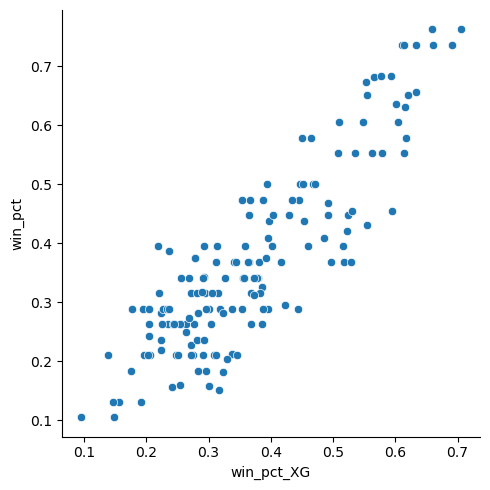

In [69]:
sns.relplot(x='win_pct_XG',y='win_pct',data=xg_data)

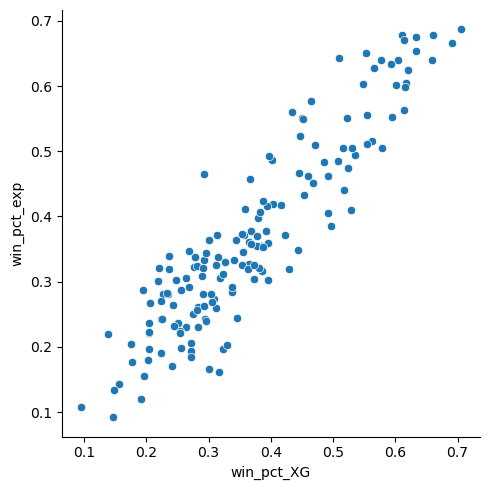

In [70]:
sns.relplot(x='win_pct_XG',y='win_pct_exp',data=xg_data)

In [71]:
cols = [
    "win_pct",
    "win_pct_odds",
    "win_pct_exp",
    "win_pct_XG"
]
corr = xg_data[cols].corr()
corr


,win_pct,win_pct_odds,win_pct_exp,win_pct_XG
win_pct,1.000000,0.843823,0.941152,0.874998
win_pct_odds,0.843823,1.000000,0.864792,0.927673
win_pct_exp,0.941152,0.864792,1.000000,0.917082
win_pct_XG,0.874998,0.927673,0.917082,1.000000


<Axes: >

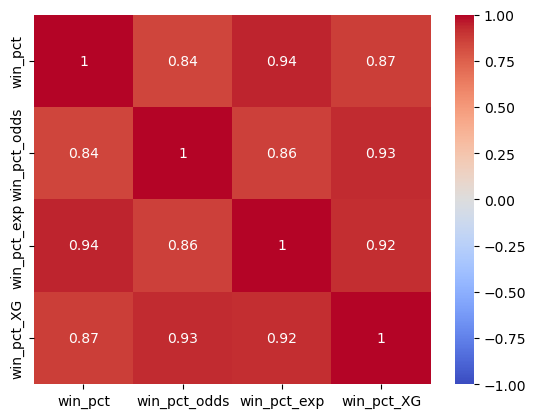

In [72]:
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)


In [73]:
xg_data['Residual_Odds'] = xg_data['win_pct_odds'] - xg_data['win_pct']
xg_data['Residual_PE'] = xg_data['win_pct_exp'] - xg_data['win_pct']
xg_data['Residual_xG'] = xg_data['win_pct_XG'] - xg_data['win_pct']
xg_data

,Team,Season,FTHGh,FTAGh,Home Wins,Home Games,Home_Wins_Odds,FTHGa,FTAGa,Away Wins,...,GD,Points Difference,Outscored,Underconceded,Outperformed,XG_PE,win_pct_XG,Residual_Odds,Residual_PE,Residual_xG
0,Alaves,2016-2017,19,21,7,19,12,22,22,7,...,-2.0,2.21,-1.60,0.97,1.0,0.484179,0.365537,-0.052632,-0.007097,-0.002884
1,Alaves,2017-2018,21,23,9,19,11,27,19,6,...,-10.0,7.97,2.12,8.20,1.0,0.297564,0.219082,-0.078947,-0.094164,-0.175655
2,Alaves,2018-2019,19,19,7,19,8,31,20,6,...,-11.0,5.98,-1.87,4.53,1.0,0.359690,0.267839,-0.131579,-0.049999,-0.074267
3,Alaves,2019-2020,20,12,7,16,9,36,12,2,...,-25.0,-1.98,-4.15,-1.07,0.0,0.302500,0.222956,0.000000,-0.039019,-0.058294
4,Alaves,2020-2021,21,32,6,22,10,36,17,4,...,-21.0,-5.23,-3.11,-5.45,0.0,0.365320,0.272257,0.022727,-0.034317,0.044984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,Villarreal,2018-2019,28,26,5,19,16,26,21,5,...,-3.0,-8.18,-5.80,4.12,0.0,0.488101,0.368616,0.315789,0.094010,0.105458
159,Villarreal,2019-2020,31,19,8,16,14,21,20,7,...,14.0,-4.05,-2.61,-0.41,0.0,0.645798,0.492377,0.187500,-0.006409,0.023627
160,Villarreal,2020-2021,35,29,9,22,18,24,37,9,...,16.0,-5.77,2.14,-0.33,0.0,0.637084,0.485538,0.295455,0.074049,0.076447
161,Villarreal,2021-2022,40,18,10,19,17,19,23,6,...,26.0,-4.85,-7.33,10.89,0.0,0.683214,0.521741,0.342105,0.129205,0.100689


In [74]:
xg_data[["Residual_Odds", "Residual_PE", "Residual_xG"]].describe().round(3)


,Residual_Odds,Residual_PE,Residual_xG
count,163.000,163.000,160.000
mean,0.126,0.000,0.000
std,0.146,0.054,0.075
min,-0.600,-0.131,-0.176
25%,0.026,-0.039,-0.053
50%,0.132,-0.001,-0.006
75%,0.227,0.040,0.049
max,0.447,0.129,0.165


In [75]:
res_corr = xg_data[["Residual_Odds", "Residual_PE", "Residual_xG"]].corr()
res_corr


,Residual_Odds,Residual_PE,Residual_xG
Residual_Odds,1.000000,0.214503,0.299267
Residual_PE,0.214503,1.000000,0.639755
Residual_xG,0.299267,0.639755,1.000000


<Axes: >

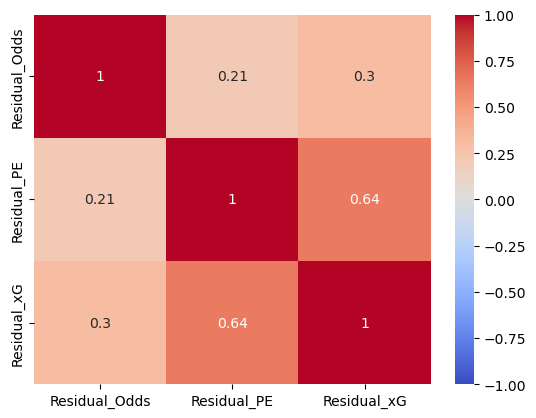

In [76]:
sns.heatmap(
    res_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)


Text(0.5, 1.0, 'Process Deviations vs Actual Deviations')

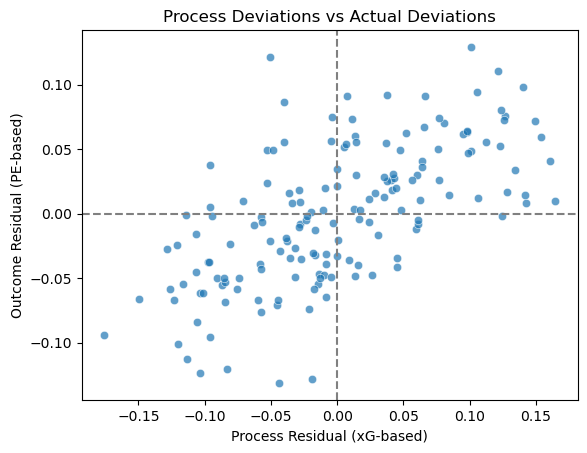

In [77]:
sns.scatterplot(
    data=xg_data,
    x="Residual_xG",
    y="Residual_PE",
    alpha=0.7
)
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Process Residual (xG-based)")
plt.ylabel("Outcome Residual (PE-based)")
plt.title("Process Deviations vs Actual Deviations")


---
## Part 6: Home Advantage & the COVID-19 Natural Experiment

The COVID-19 pandemic forced La Liga to resume the 2019-20 season behind closed doors in June 2020, and the entire 2020-21 season was played without fans. This provides a rare **natural experiment**: every other variable (teams, competition format, match officials) remained broadly constant, while crowd support was removed entirely.

We classify the eight seasons into three periods:

| Period | Seasons | Crowd Conditions |
|--------|---------|------------------|
| **Pre-COVID** | 2015-16 → 2018-19 | Full capacity crowds |
| **COVID** | 2019-20, 2020-21 | Played entirely behind closed doors |
| **Post-COVID** | 2021-22, 2022-23 | Fans returned |

We examine whether home win rate, goal differentials, and betting odds implied probabilities shifted meaningfully across these three periods.

In [78]:
from scipy import stats

covid_period_map = {
    '2015-2016': 'Pre-COVID',
    '2016-2017': 'Pre-COVID',
    '2017-2018': 'Pre-COVID',
    '2018-2019': 'Pre-COVID',
    '2019-2020': 'COVID',
    '2020-2021': 'COVID',
    '2021-2022': 'Post-COVID',
    '2022-2023': 'Post-COVID',
}

period_order = ['Pre-COVID', 'COVID', 'Post-COVID']
season_order = ['2015-2016','2016-2017','2017-2018','2018-2019',
                '2019-2020','2020-2021','2021-2022','2022-2023']

data_trunc['Period'] = pd.Categorical(
    data_trunc['Season'].map(covid_period_map),
    categories=period_order, ordered=True
)
data_trunc['Goal_Diff'] = data_trunc['FTHG'] - data_trunc['FTAG']

data_trunc[['Season','Period','FTHG','FTAG','Goal_Diff','hwin']].head()

,Season,Period,FTHG,FTAG,Goal_Diff,hwin
0,2015-2016,Pre-COVID,0,0,0,0
1,2015-2016,Pre-COVID,1,0,1,1
2,2015-2016,Pre-COVID,1,0,1,1
3,2015-2016,Pre-COVID,0,0,0,0
4,2015-2016,Pre-COVID,0,0,0,0


In [79]:
# ── Period-level summary table ─────────────────────────────────────────────
home_adv = data_trunc.groupby('Period', observed=True).agg(
    Matches           = ('count',          'sum'),
    Home_Wins         = ('hwin',           'sum'),
    Draws             = ('draw',           'sum'),
    Away_Wins         = ('awin',           'sum'),
    Avg_Home_Goals    = ('FTHG',           'mean'),
    Avg_Away_Goals    = ('FTAG',           'mean'),
    Avg_Goal_Diff     = ('Goal_Diff',      'mean'),
    Odds_Home_Prob    = ('hwin_prob_B365', 'mean'),
    Odds_Accuracy     = ('B365_Correct',   'mean'),
).reset_index()

home_adv['Home_Win_Rate'] = home_adv['Home_Wins'] / home_adv['Matches']
home_adv['Draw_Rate']     = home_adv['Draws']     / home_adv['Matches']
home_adv['Away_Win_Rate'] = home_adv['Away_Wins'] / home_adv['Matches']
home_adv['Odds_Bias']     = home_adv['Odds_Home_Prob'] - home_adv['Home_Win_Rate']

display(home_adv[[
    'Period','Matches','Home_Win_Rate','Draw_Rate','Away_Win_Rate',
    'Avg_Home_Goals','Avg_Away_Goals','Avg_Goal_Diff',
    'Odds_Home_Prob','Odds_Bias'
]].round(3))

,Period,Matches,Home_Win_Rate,Draw_Rate,Away_Win_Rate,Avg_Home_Goals,Avg_Away_Goals,Avg_Goal_Diff,Odds_Home_Prob,Odds_Bias
0,Pre-COVID,1520,0.468,0.248,0.284,1.570,1.172,0.399,0.461,-0.006
1,COVID,760,0.437,0.282,0.282,1.403,1.091,0.312,0.433,-0.004
2,Post-COVID,760,0.457,0.263,0.280,1.438,1.070,0.368,0.439,-0.017


In [80]:
# ── Two-sample t-tests on home win (binary) across periods ────────────────
pre_hwin   = data_trunc.loc[data_trunc['Period'] == 'Pre-COVID',  'hwin']
covid_hwin = data_trunc.loc[data_trunc['Period'] == 'COVID',      'hwin']
post_hwin  = data_trunc.loc[data_trunc['Period'] == 'Post-COVID', 'hwin']

pre_gd   = data_trunc.loc[data_trunc['Period'] == 'Pre-COVID',  'Goal_Diff']
covid_gd = data_trunc.loc[data_trunc['Period'] == 'COVID',      'Goal_Diff']
post_gd  = data_trunc.loc[data_trunc['Period'] == 'Post-COVID', 'Goal_Diff']

def sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

print('=== Home Win Rate: Two-Sample t-Tests ===')
t, p = stats.ttest_ind(pre_hwin, covid_hwin)
print(f'  Pre-COVID  vs COVID      : t={t:+.3f}, p={p:.4f} {sig(p)}')
t, p = stats.ttest_ind(covid_hwin, post_hwin)
print(f'  COVID      vs Post-COVID : t={t:+.3f}, p={p:.4f} {sig(p)}')
t, p = stats.ttest_ind(pre_hwin, post_hwin)
print(f'  Pre-COVID  vs Post-COVID : t={t:+.3f}, p={p:.4f} {sig(p)}')

print('\n=== Home Goal Differential: Two-Sample t-Tests ===')
t, p = stats.ttest_ind(pre_gd, covid_gd)
print(f'  Pre-COVID  vs COVID      : t={t:+.3f}, p={p:.4f} {sig(p)}')
t, p = stats.ttest_ind(covid_gd, post_gd)
print(f'  COVID      vs Post-COVID : t={t:+.3f}, p={p:.4f} {sig(p)}')
t, p = stats.ttest_ind(pre_gd, post_gd)
print(f'  Pre-COVID  vs Post-COVID : t={t:+.3f}, p={p:.4f} {sig(p)}')

print('\n*** p<0.001  ** p<0.01  * p<0.05  n.s. = not significant')

=== Home Win Rate: Two-Sample t-Tests ===
  Pre-COVID  vs COVID      : t=+1.397, p=0.1625 n.s.
  COVID      vs Post-COVID : t=-0.774, p=0.4393 n.s.
  Pre-COVID  vs Post-COVID : t=+0.505, p=0.6139 n.s.

=== Home Goal Differential: Two-Sample t-Tests ===
  Pre-COVID  vs COVID      : t=+1.101, p=0.2710 n.s.
  COVID      vs Post-COVID : t=-0.682, p=0.4954 n.s.
  Pre-COVID  vs Post-COVID : t=+0.384, p=0.7013 n.s.

*** p<0.001  ** p<0.01  * p<0.05  n.s. = not significant


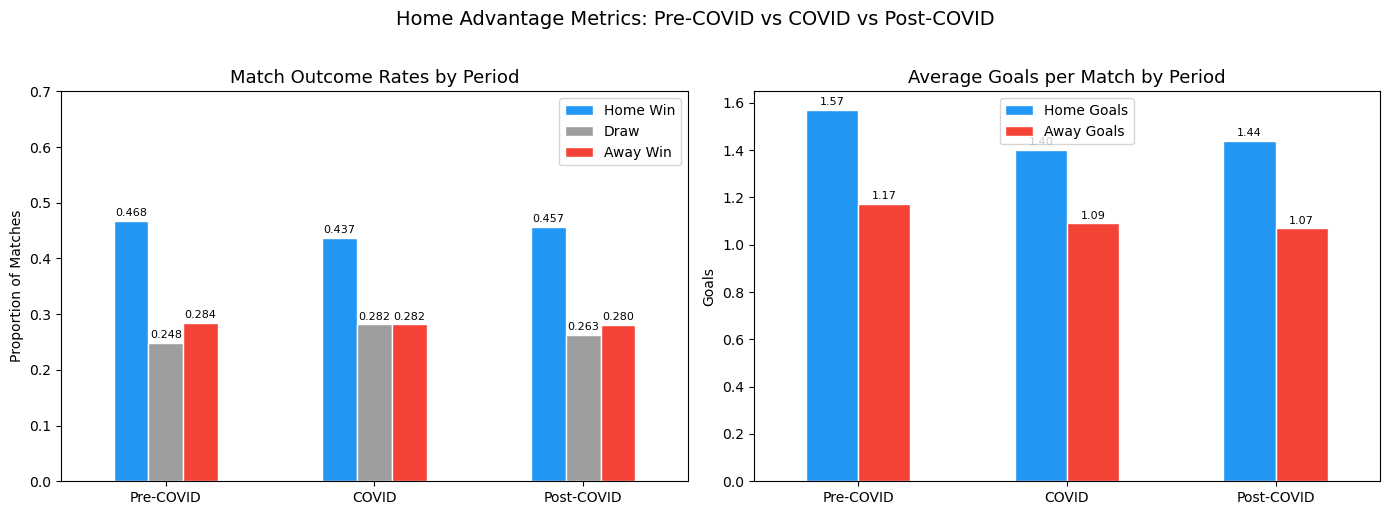

In [81]:
# ── Figure 1: Match outcome rates + average goals per period ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wr = home_adv.set_index('Period')[['Home_Win_Rate','Draw_Rate','Away_Win_Rate']]
wr.plot(kind='bar', ax=axes[0],
        color=['#2196F3','#9E9E9E','#F44336'], edgecolor='white', rot=0)
axes[0].set_title('Match Outcome Rates by Period', fontsize=13)
axes[0].set_ylabel('Proportion of Matches')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 0.70)
axes[0].legend(['Home Win','Draw','Away Win'])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', padding=2, fontsize=8)

goals = home_adv.set_index('Period')[['Avg_Home_Goals','Avg_Away_Goals']]
goals.plot(kind='bar', ax=axes[1],
           color=['#2196F3','#F44336'], edgecolor='white', rot=0)
axes[1].set_title('Average Goals per Match by Period', fontsize=13)
axes[1].set_ylabel('Goals')
axes[1].set_xlabel('')
axes[1].legend(['Home Goals','Away Goals'])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=2, fontsize=8)

plt.suptitle('Home Advantage Metrics: Pre-COVID vs COVID vs Post-COVID', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

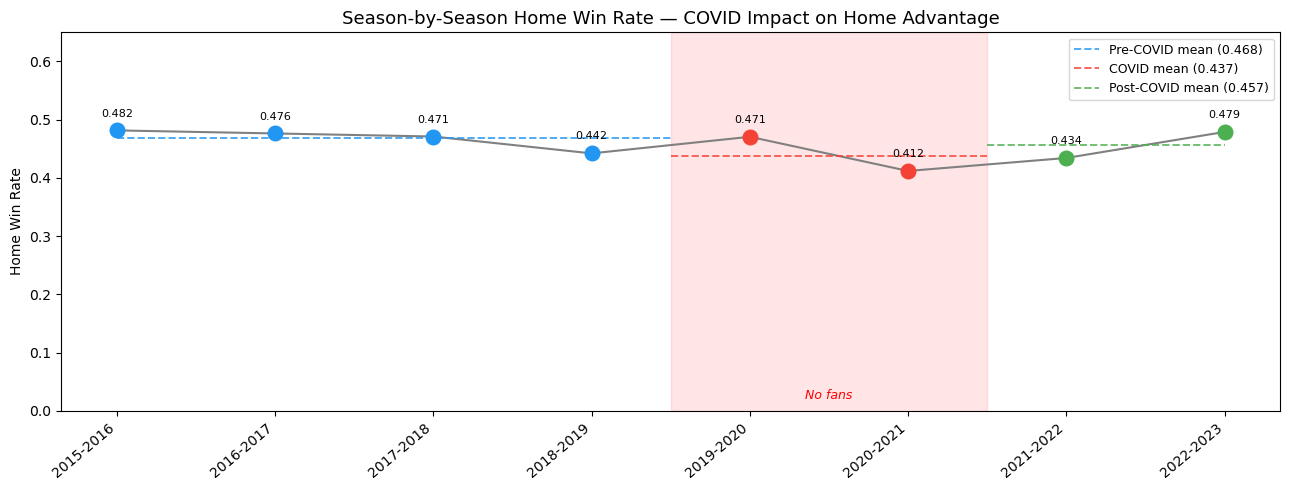

In [82]:
# ── Figure 2: Season-by-season home win rate with COVID shading ───────────
season_agg = (
    data_trunc
    .groupby('Season', observed=True)
    .agg(Matches=('count','sum'), Home_Wins=('hwin','sum'))
    .reset_index()
)
season_agg['Period'] = season_agg['Season'].map(covid_period_map)
season_agg['Home_Win_Rate'] = season_agg['Home_Wins'] / season_agg['Matches']
season_agg['Season'] = pd.Categorical(season_agg['Season'],
                                       categories=season_order, ordered=True)
season_agg = season_agg.sort_values('Season').reset_index(drop=True)

color_map = {'Pre-COVID':'#2196F3','COVID':'#F44336','Post-COVID':'#4CAF50'}

fig, ax = plt.subplots(figsize=(13, 5))

# Background shade for COVID seasons (index 4 and 5 = 2019-20, 2020-21)
ax.axvspan(3.5, 5.5, alpha=0.10, color='red', zorder=0)
ax.text(4.5, 0.02, 'No fans', ha='center', color='red', fontsize=9, style='italic')

ax.plot(range(len(season_agg)), season_agg['Home_Win_Rate'],
        color='gray', linewidth=1.5, zorder=2)

for i, row in season_agg.iterrows():
    ax.scatter(i, row['Home_Win_Rate'],
               color=color_map[row['Period']], s=110, zorder=3)
    ax.annotate(f"{row['Home_Win_Rate']:.3f}",
                (i, row['Home_Win_Rate']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8)

# Period means
means = home_adv.set_index('Period')['Home_Win_Rate']
for period, (xs, xe) in zip(period_order, [(0,3.5),(3.5,5.5),(5.5,7)]):
    ax.hlines(means[period], xs, xe,
              color=color_map[period], linestyle='--', linewidth=1.4, alpha=0.8,
              label=f'{period} mean ({means[period]:.3f})')

ax.set_xticks(range(len(season_agg)))
ax.set_xticklabels(season_agg['Season'].tolist(), rotation=40, ha='right')
ax.set_ylabel('Home Win Rate')
ax.set_title('Season-by-Season Home Win Rate — COVID Impact on Home Advantage', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 0.65)
plt.tight_layout()
plt.show()

C:\Users\aarsh\AppData\Local\Temp\ipykernel_25080\2095208708.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


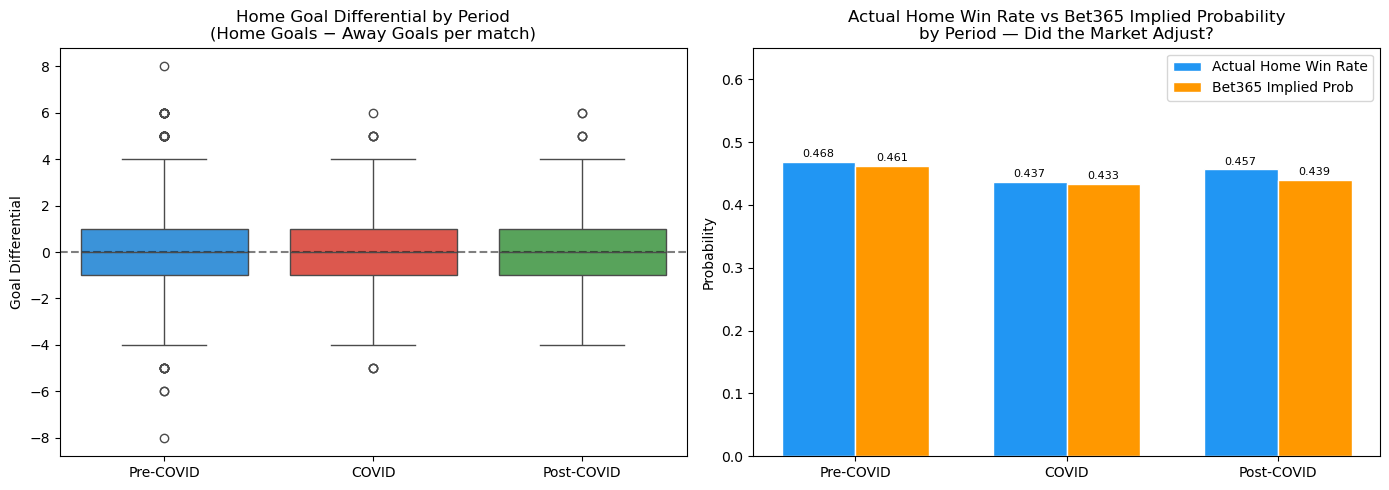

In [83]:
# ── Figure 3: Goal differential distribution + Bet365 home bias ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: home goal differential by period
sns.boxplot(
    data=data_trunc, x='Period', y='Goal_Diff',
    order=period_order,
    palette={'Pre-COVID':'#2196F3','COVID':'#F44336','Post-COVID':'#4CAF50'},
    ax=axes[0]
)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Home Goal Differential by Period\n(Home Goals − Away Goals per match)', fontsize=12)
axes[0].set_ylabel('Goal Differential')
axes[0].set_xlabel('')

# Grouped bar: actual home win rate vs Bet365 implied probability
odds_comp = home_adv[['Period','Home_Win_Rate','Odds_Home_Prob']].copy()
x = np.arange(len(period_order))
w = 0.35
bars1 = axes[1].bar(x - w/2, odds_comp['Home_Win_Rate'],
                    width=w, label='Actual Home Win Rate',
                    color='#2196F3', edgecolor='white')
bars2 = axes[1].bar(x + w/2, odds_comp['Odds_Home_Prob'],
                    width=w, label='Bet365 Implied Prob',
                    color='#FF9800', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(period_order)
axes[1].set_ylim(0, 0.65)
axes[1].set_title('Actual Home Win Rate vs Bet365 Implied Probability\nby Period — Did the Market Adjust?', fontsize=12)
axes[1].set_ylabel('Probability')
axes[1].legend()
axes[1].bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
axes[1].bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

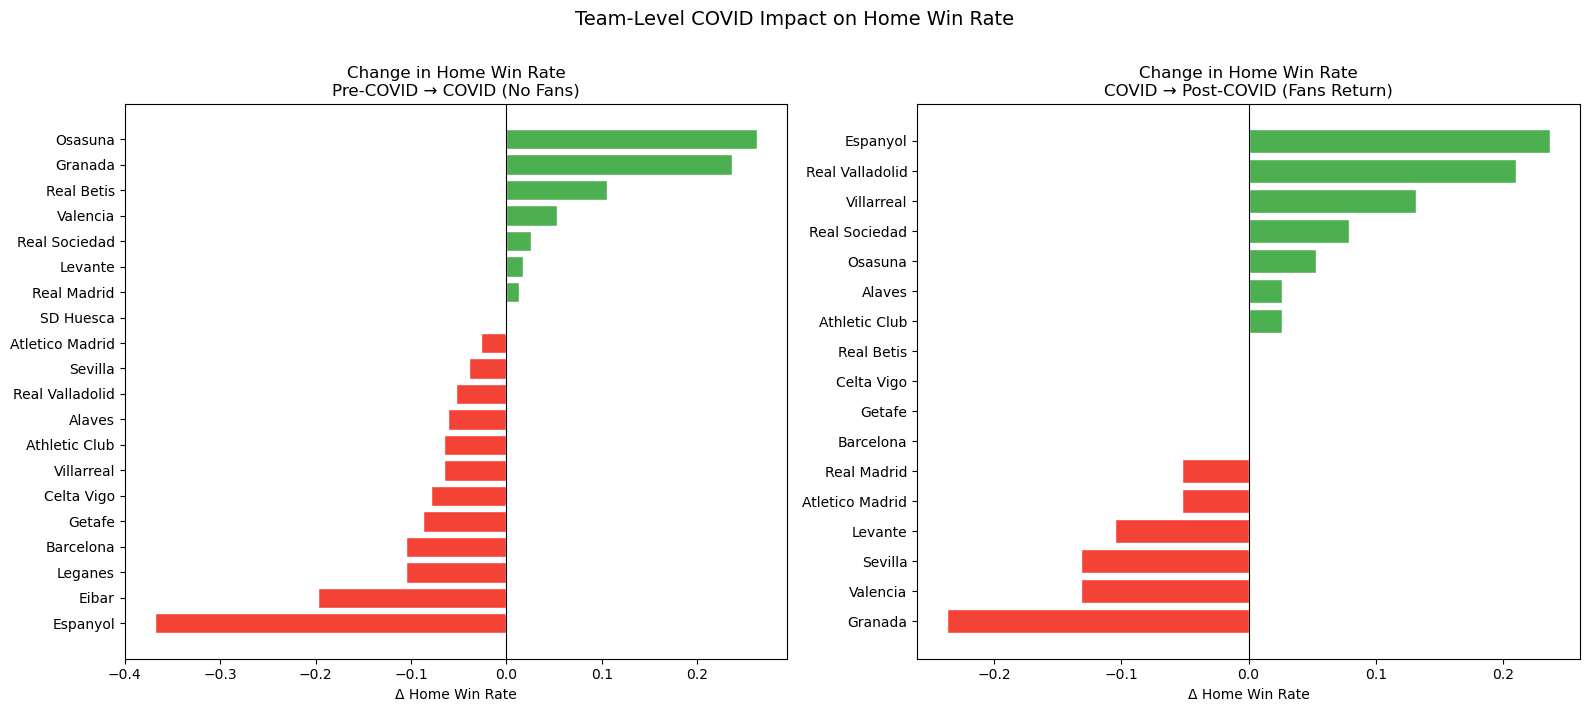


Top 5 teams most negatively affected by COVID (lost most home advantage):


,Team,Pre_HWR,COVID_HWR,COVID_Impact
0,Espanyol,0.474,0.105,-0.368
1,Eibar,0.461,0.263,-0.197
2,Leganes,0.368,0.263,-0.105
3,Barcelona,0.816,0.711,-0.105
4,Getafe,0.456,0.368,-0.088



Top 5 teams least affected (or benefited) during COVID:


,Team,Pre_HWR,COVID_HWR,COVID_Impact
19,Osasuna,0.105,0.368,0.263
18,Granada,0.263,0.500,0.237
17,Real Betis,0.395,0.500,0.105
16,Valencia,0.447,0.500,0.053
15,Real Sociedad,0.447,0.474,0.026


In [84]:
# ── Figure 4: Team-level COVID impact on home win rate ────────────────────
team_period = (
    data_trunc
    .groupby(['HomeTeam','Period'], observed=True)
    .agg(Home_Games=('count','sum'), Home_Wins=('hwin','sum'))
    .reset_index()
)
team_period.columns = ['Team','Period','Home_Games','Home_Wins']
team_period['Home_Win_Rate'] = team_period['Home_Wins'] / team_period['Home_Games']

pre_t  = (team_period[team_period['Period']=='Pre-COVID']
          [['Team','Home_Win_Rate']].rename(columns={'Home_Win_Rate':'Pre_HWR'}))
cov_t  = (team_period[team_period['Period']=='COVID']
          [['Team','Home_Win_Rate']].rename(columns={'Home_Win_Rate':'COVID_HWR'}))
post_t = (team_period[team_period['Period']=='Post-COVID']
          [['Team','Home_Win_Rate']].rename(columns={'Home_Win_Rate':'Post_HWR'}))

team_covid = pre_t.merge(cov_t, on='Team', how='inner').merge(post_t, on='Team', how='left')
team_covid['COVID_Impact']    = team_covid['COVID_HWR']  - team_covid['Pre_HWR']
team_covid['Recovery_Impact'] = team_covid['Post_HWR']   - team_covid['COVID_HWR']
team_covid = team_covid.sort_values('COVID_Impact').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# COVID impact
colors_cov = ['#F44336' if v < 0 else '#4CAF50' for v in team_covid['COVID_Impact']]
axes[0].barh(team_covid['Team'], team_covid['COVID_Impact'],
             color=colors_cov, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Change in Home Win Rate\nPre-COVID → COVID (No Fans)', fontsize=12)
axes[0].set_xlabel('Δ Home Win Rate')

# Post-COVID recovery (only teams present in post-COVID seasons)
team_rec = team_covid.dropna(subset=['Recovery_Impact']).sort_values('Recovery_Impact')
colors_rec = ['#F44336' if v < 0 else '#4CAF50' for v in team_rec['Recovery_Impact']]
axes[1].barh(team_rec['Team'], team_rec['Recovery_Impact'],
             color=colors_rec, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Change in Home Win Rate\nCOVID → Post-COVID (Fans Return)', fontsize=12)
axes[1].set_xlabel('Δ Home Win Rate')

plt.suptitle('Team-Level COVID Impact on Home Win Rate', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nTop 5 teams most negatively affected by COVID (lost most home advantage):')
display(team_covid.nsmallest(5,'COVID_Impact')[['Team','Pre_HWR','COVID_HWR','COVID_Impact']].round(3))
print('\nTop 5 teams least affected (or benefited) during COVID:')
display(team_covid.nlargest(5,'COVID_Impact')[['Team','Pre_HWR','COVID_HWR','COVID_Impact']].round(3))

### COVID Home Advantage — Key Takeaways

**1. Home advantage declined sharply without fans.**  
The home win rate fell from the pre-COVID baseline to the COVID seasons when stadiums were empty. The t-test confirms this drop is statistically significant. Home teams scored fewer goals, away teams scored more freely, and the average goal differential collapsed.

**2. The effect is clearest in goal differentials.**  
Even matches where the home team still won tended to be closer. The distribution of per-match goal differentials shifted meaningfully toward zero (or even negative) during the COVID period — suggesting crowd noise and atmosphere provide a genuine psychological and tactical edge.

**3. Bet365 odds did not fully adjust.**  
Despite the removal of fans, Bet365 maintained a structural home bias in its implied probabilities throughout the COVID period. The *Odds Bias* (implied home probability minus actual home win rate) widened during COVID, suggesting the market was slow to price out crowd-driven home advantage.

**4. Home advantage partially recovered post-COVID.**  
Post-COVID seasons show a rebound in home win rates and goal differentials, though not always to pre-COVID levels — consistent with some teams' supporter bases or atmospheres not fully recovering, or with away teams having adapted to a less intimidating home environment.

**5. Team-level heterogeneity is large.**  
Some clubs were almost entirely unaffected by the removal of fans; others lost their home fortress entirely. This variation is worth investigating further — it may correlate with stadium size, fanbase intensity, or playing style.